In [72]:
import sys

sys.path.insert(1, '../ML_pipeline')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE

### For our baseline model we will only consider four measurements: the mean heart rate, and the mean acceleration magnitudes from each of the three sensors. First we read in the features:

In [73]:
full_df = pd.read_csv('features.csv')

device_list = ['hand',
               'chest',
               'ankle']

axes_list = ['amp']

sensor_list = ['acc16']

stat_list = ['mean']

feature_list = []

for stat in stat_list:
    feature_list.append('heart_rate_'+stat)

for device in device_list:
    for sensor in sensor_list:
        
        for axis in axes_list:
            for stat in stat_list:
                label = '_'.join([device,sensor,axis,stat])
                feature_list.append(label)
    


X = full_df[feature_list]
y = full_df['activity_id']
groups = full_df['interval_id']

### We will consider three classification approaches: full activity classification (y), minimal grouping of similar activities (y_sim), and aggressive grouping of activities by low, medium, and high activity (y_LMH).

In [74]:
# creates new activity dataframe based on input groups
# group_dict is a dictionary where keys are the desired group labels and values are the lists of activity ids in the new group
def group_activities(y,group_dict):
    y_new = y.copy(deep=True)

    for group in group_dict.keys():
        for id in group_dict[group]:
            y_new.replace(to_replace=id,value=group,inplace=True)

    return y_new

name_map = {
        0: 'Transient/Break', 1: 'Lying down', 2: 'Sitting', 3: 'Standing', 
        4: 'Walking', 5: 'Running', 6: 'Cycling', 7: 'Nordic walking', 
        9: 'Watching TV', 10: 'Computer work', 11: 'Car driving', 
        12: 'Ascending stairs', 13: 'Descending stairs', 16: 'Vacuum cleaning', 
        17: 'Ironing', 18: 'Folding laundry', 19: 'House cleaning', 
        20: 'Playing soccer', 24: 'Rope jumping'
    }

'Similar activities grouping:'
sim_groups = {101:[1,2], #lying, sitting
              102:[4,7], #walking, nordic walking
              103:[16,17] #vacuum cleaning, ironing
              }
name_map_sim = {
    101: "Resting",
    3: "Standing",
    102: "Walking",
    5: "Running",
    6: "Cycling",
    9: "Watching TV",
    10: "Computer Work",
    11: "Car Driving",
    12: "Ascending \nStairs",
    13: "Descending \nStairs",
    103: "House Work",
    18: "Folding Laundry",
    19: "House Cleaning",
    20: "Playing Soccer",
    24: "Rope \nJumping",
}

y_sim = group_activities(y,sim_groups)

'Low/medium/high activity grouping:'
LMH_groups = {101:[1,2,3], #lying, sitting, standing
              102:[4,7,12,13,16,17], #walking, nordic walking, ascending stairs, descending stairs, vacuum cleaning, ironing
              103:[5,6,24] #running, cycling, rope jumping
              } 

name_map_LMH = {
    101: "Low \nActivity",
    102: "Medium \nActivity",
    103: "High \nActivity",
}

y_LMH = group_activities(y,LMH_groups)

### This is our function to perform and evaluate the fit. To classify a segment, we look at the normalized distance to the mean of each activity in the 4-dimensional feature space. The segment is assigned to the activity it is nearest to.

In [75]:
def fit_baseline(y):

    fold_rows = []
    all_true = []
    all_pred = []

    labels_sorted = np.sort(y.unique())
    gkf = GroupKFold(n_splits=3,shuffle=True,random_state=43)

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        activities = y.unique()
        means = {}
        stds = {}

        for act in activities:
                mean = X_train[y_train==act].mean().values
                std = X_train[y_train==act].std().values
                means[act] = mean
                stds[act] = std


        means_arr = np.zeros([len(activities),1+len(means[activities[0]])])
        means_arr[:,0] = activities

        for j in range(means_arr.shape[0]):
                key = means_arr[j,0]
                means_arr[j,1:] = means[key]


        stds_arr = np.zeros([len(activities),1+len(stds[activities[0]])])
        stds_arr[:,0] = activities

        for j in range(stds_arr.shape[0]):
                key = stds_arr[j,0]
                stds_arr[j,1:] = stds[key]


        def test_row(row):
                test_arr = np.zeros(means_arr.shape)
                test_arr[:,0] = means_arr[:,0]
                test_arr[:,1:] = row.values
                test_arr[:,1:] -= means_arr[:,1:]
                test_arr[:,1:] = test_arr[:,1:] / stds_arr[:,1:]
                norms = np.linalg.norm(test_arr[:,1:],axis=1)
                ind_best = np.argmin(norms)

                return activities[ind_best]

        y_pred = X_test.apply(test_row,axis=1)

        acc = accuracy_score(y_test, y_pred)
        prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        )

        fold_rows.append(
            {
                "fold": fold_idx,
                "accuracy": acc,
                "macro_precision": prec_macro,
                "macro_recall": rec_macro,
                "macro_f1": f1_macro,
                "n_test": len(test_idx),
            }
        )

        all_true.append(y_test.to_numpy())
        all_pred.append(y_pred)

        print(
            f"Fold {fold_idx}: "
            f"acc={acc:.4f}, macro_f1={f1_macro:.4f}, n_test={len(test_idx)}"
        )

    cv_metrics = pd.DataFrame(fold_rows)
    print("\n5-fold metrics:")
    print(cv_metrics)

    print("\nAverage performance (5-fold):")
    print(
        cv_metrics[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]
        .mean()
        .to_frame("mean")
        .join(
            cv_metrics[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]
            .std(ddof=1)
            .to_frame("std")
        )
    )

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    print("\nClassification report (all fold predictions combined):")
    print(classification_report(y_true_all, y_pred_all, labels=labels_sorted, zero_division=0))

    return y_true_all,y_pred_all,y_test,y_pred,labels_sorted

### Here we test our baseline model for each of the three classification approaches.

In [76]:
#testing with full activity list
y_true_all,y_pred_all,y_test,y_pred,labels = fit_baseline(y)

Fold 1: acc=0.4349, macro_f1=0.3468, n_test=4516
Fold 2: acc=0.5741, macro_f1=0.5636, n_test=5466
Fold 3: acc=0.4302, macro_f1=0.3891, n_test=5667

5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.434898         0.489460      0.384840  0.346803    4516
1     2  0.574094         0.667717      0.621688  0.563624    5466
2     3  0.430210         0.481014      0.451219  0.389054    5667

Average performance (5-fold):
                     mean       std
accuracy         0.479734  0.081752
macro_precision  0.546064  0.105439
macro_recall     0.485915  0.122177
macro_f1         0.433160  0.114943

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

         1.0       0.83      0.90      0.87      1599
         2.0       0.41      0.38      0.40      1539
         3.0       0.55      0.42      0.48      1563
         4.0       0.85      0.24      0.37      1992
         5.0       0.70      0

In [77]:
#testing with similar activities grouped
y_true_all_sim,y_pred_all_sim,y_test_sim,y_pred_sim,labels_sim = fit_baseline(y_sim)

Fold 1: acc=0.4674, macro_f1=0.4219, n_test=4516
Fold 2: acc=0.6085, macro_f1=0.6059, n_test=5466
Fold 3: acc=0.5103, macro_f1=0.4104, n_test=5667

5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.467449         0.525817      0.528621  0.421944    4516
1     2  0.608489         0.661927      0.670802  0.605879    5466
2     3  0.510323         0.472476      0.495514  0.410379    5667

Average performance (5-fold):
                     mean       std
accuracy         0.528754  0.072304
macro_precision  0.553407  0.097692
macro_recall     0.564979  0.093128
macro_f1         0.479400  0.109686

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

         3.0       0.56      0.34      0.42      1563
         5.0       0.71      0.32      0.44       756
         6.0       0.93      0.64      0.75      1320
        12.0       0.23      0.53      0.32       887
        13.0       0.15      0

In [78]:
#testing with low/medium/high groups
y_true_all_LMH,y_pred_all_LMH,y_test_LMH,y_pred_LMH,labels_LMH = fit_baseline(y_LMH)

Fold 1: acc=0.6829, macro_f1=0.6700, n_test=4516
Fold 2: acc=0.6912, macro_f1=0.6371, n_test=5466
Fold 3: acc=0.6268, macro_f1=0.5631, n_test=5667

5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.682905         0.718521      0.705730  0.669972    4516
1     2  0.691182         0.637332      0.659803  0.637118    5466
2     3  0.626787         0.571536      0.613952  0.563050    5667

Average performance (5-fold):
                     mean       std
accuracy         0.666958  0.035035
macro_precision  0.642463  0.073626
macro_recall     0.659828  0.045889
macro_f1         0.623380  0.054769

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

       101.0       0.86      0.80      0.83      4701
       102.0       0.77      0.57      0.66      8570
       103.0       0.36      0.73      0.48      2378

    accuracy                           0.67     15649
   macro avg       0.66      

In [79]:
def plot_cm(y_true_all,y_pred_all,labels_sorted,activity_name_map,name):

    # Activity labels after class-combination:
    # 2 -> 1 (Resting), 7 -> 4 (Walking), 17 -> 16 (House Work)

    # Use combined-category names in confusion matrix axes.
    # activity_name_map = {
    #     0: 'Transient/Break', 1: 'Lying down', 2: 'Sitting', 3: 'Standing', 
    #     4: 'Walking', 5: 'Running', 6: 'Cycling', 7: 'Nordic walking', 
    #     9: 'Watching TV', 10: 'Computer work', 11: 'Car driving', 
    #     12: 'Ascending stairs', 13: 'Descending stairs', 16: 'Vacuum cleaning', 
    #     17: 'Ironing', 18: 'Folding laundry', 19: 'House cleaning', 
    #     20: 'Playing soccer', 24: 'Rope jumping'
    # }

    def _label_with_prefix(activity_id, prefix):
        name = activity_name_map.get(int(activity_id), f"ID{int(activity_id)}")
        return f"{name}"

    cm = pd.DataFrame(
        confusion_matrix(y_true_all, y_pred_all, labels=labels_sorted),
        index=[_label_with_prefix(lbl, "T") for lbl in labels_sorted],
        columns=[_label_with_prefix(lbl, "P") for lbl in labels_sorted],
    )

    print("\nConfusion matrix (5-fold pooled predictions):")
    print(cm)




    # Pretty, colorized confusion matrix saved as PNG.
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm.values, cmap="Blues")

    ax.set_xticks(np.arange(len(cm.columns)))
    ax.set_yticks(np.arange(len(cm.index)))
    ax.set_xticklabels(cm.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm.index)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Baseline Model group K splitting Confusion Matrix ("+name+")")

    # Annotate each cell with count value.
    threshold = cm.values.max() / 2 if cm.values.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm.iat[i, j]
            color = "white" if value > threshold else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
    fig.tight_layout()

    output_png = "baseline_group_K_split_confusion_matrix_"+name.split(' ')[0]+".png"
    fig.savefig(output_png, dpi=200, bbox_inches="tight")
    print(f"\nSaved confusion group K split matrix PNG: {output_png}")
    plt.show()

def plot_cm_test(y_test,y_pred,labels_sorted,activity_name_map,name):


    def _label_with_prefix(activity_id, prefix):
        name = activity_name_map.get(int(activity_id), f"ID{int(activity_id)}")
        return f"{name}"

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=labels_sorted),
        index=[_label_with_prefix(lbl, "T") for lbl in labels_sorted],
        columns=[_label_with_prefix(lbl, "P") for lbl in labels_sorted],
    )

    print("\nConfusion matrix (test set):")
    print(cm)




    # Pretty, colorized confusion matrix saved as PNG.
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm.values, cmap="Blues")

    ax.set_xticks(np.arange(len(cm.columns)))
    ax.set_yticks(np.arange(len(cm.index)))
    ax.set_xticklabels(cm.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm.index)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Baseline Confusion Matrix ("+name+")")

    # Annotate each cell with count value.
    threshold = cm.values.max() / 2 if cm.values.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm.iat[i, j]
            color = "white" if value > threshold else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
    fig.tight_layout()

    output_png = "baseline_confusion_matrix_"+name.split(' ')[0]+".png"
    fig.savefig(output_png, dpi=200, bbox_inches="tight")
    print(f"\nSaved confusion matrix PNG: {output_png}")
    plt.show()


Confusion matrix (5-fold pooled predictions):
                   Lying down  Sitting  Standing  Walking  Running  Cycling  \
Lying down               1445       11        13        0        0        0   
Sitting                   285      588       376        0        0        0   
Standing                    0      508       659        0        0        0   
Walking                     0        1         0      470        6        0   
Running                     0        1         0        1      244        1   
Cycling                     0        0         0        0        0      827   
Nordic walking              0        0         0       32        5        2   
Ascending stairs            0        0         0       29       24        5   
Descending stairs           0        0         2       19       48        0   
Vacuum cleaning             0        4         1        0        0       28   
Ironing                     1      313       144        0        0       15   
Rope 

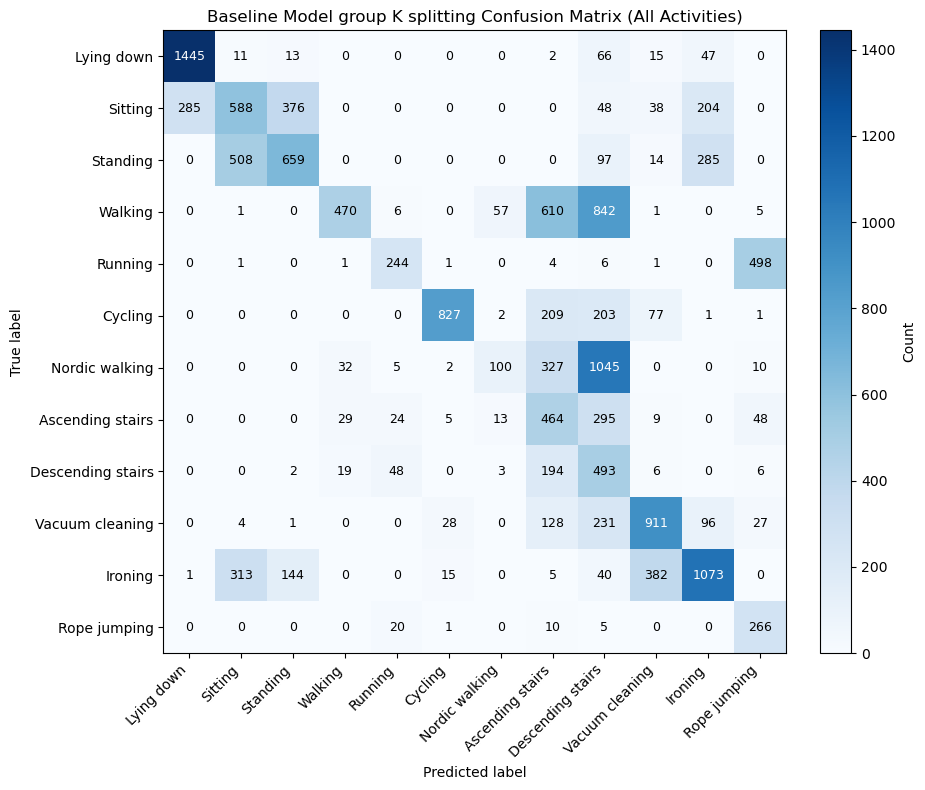


Confusion matrix (test set):
                   Lying down  Sitting  Standing  Walking  Running  Cycling  \
Lying down                625        3         4        0        0        0   
Sitting                   192      260         3        0        0        0   
Standing                    0      165        13        0        0        0   
Walking                     0        0         0      202        1        0   
Running                     0        0         0        0        0        0   
Cycling                     0        0         0        0        0      326   
Nordic walking              0        0         0       13        0        0   
Ascending stairs            0        0         0       14       24        2   
Descending stairs           0        0         0        0        7        0   
Vacuum cleaning             0        1         0        0        0       21   
Ironing                     0      301        14        0        0        0   
Rope jumping          

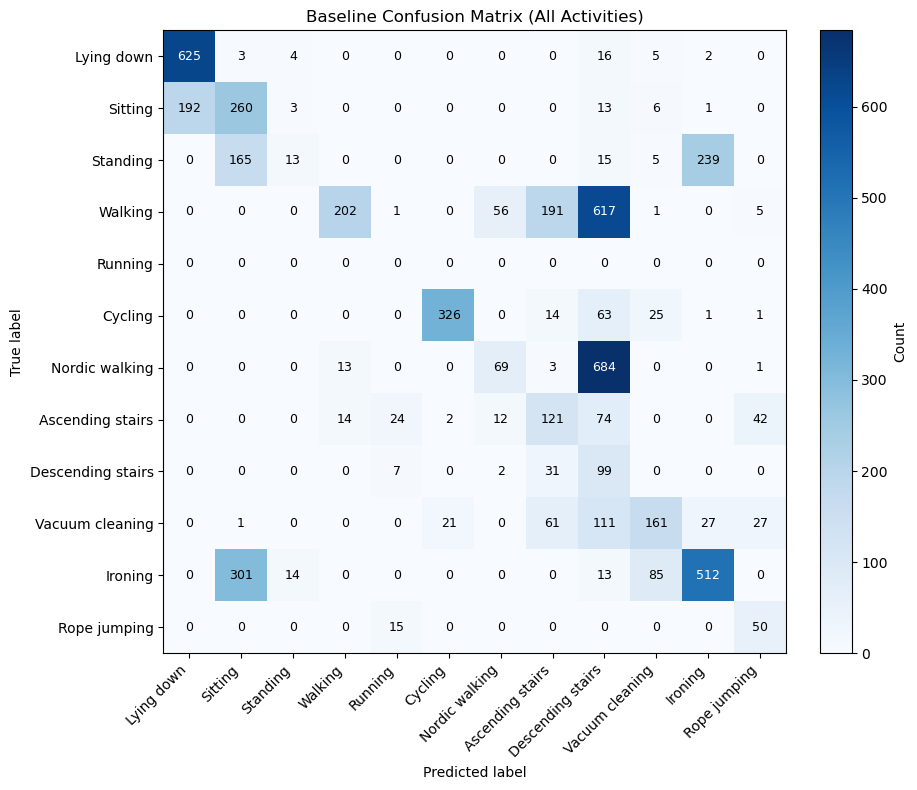

In [80]:
plot_cm(y_true_all,y_pred_all,labels,name_map,name='All Activities')
plot_cm_test(y_test,y_pred,labels,name_map,name='All Activities')


Confusion matrix (5-fold pooled predictions):
                     Standing  Running  Cycling  Ascending \nStairs  \
Standing                  525        0        0                   0   
Running                     1      244        1                   4   
Cycling                     0        0      841                 214   
Ascending \nStairs          0       23        5                 467   
Descending \nStairs         2       48        0                 198   
Rope \nJumping              0       20        1                  10   
Resting                   265        0        1                   5   
Walking                     0       10        0                 840   
House Work                145        0       59                 283   

                     Descending \nStairs  Rope \nJumping  Resting  Walking  \
Standing                              27               0      522        0   
Running                                5             498        0        1   
Cycling 

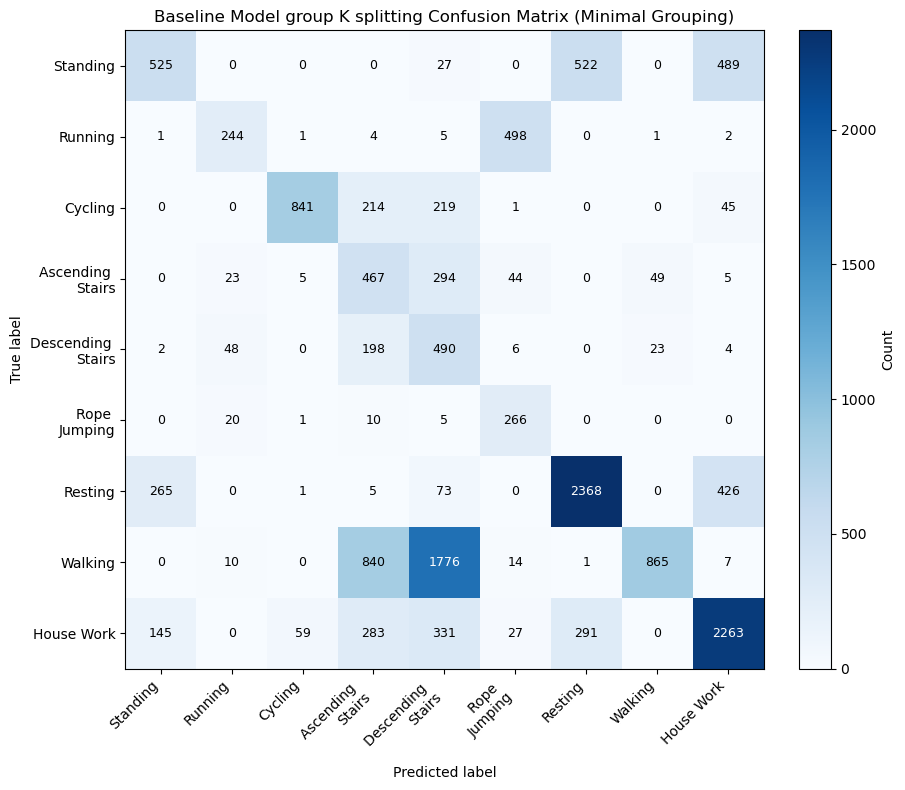


Confusion matrix (test set):
                     Standing  Running  Cycling  Ascending \nStairs  \
Standing                    9        0        0                   0   
Running                     0        0        0                   0   
Cycling                     0        0      326                  16   
Ascending \nStairs          0       23        2                 120   
Descending \nStairs         0        7        0                  31   
Rope \nJumping              0       15        0                   0   
Resting                     4        0        0                   0   
Walking                     0        0        0                 191   
House Work                 32        0       21                  69   

                     Descending \nStairs  Rope \nJumping  Resting  Walking  \
Standing                              11               0      169        0   
Running                                0               0        0        0   
Cycling                  

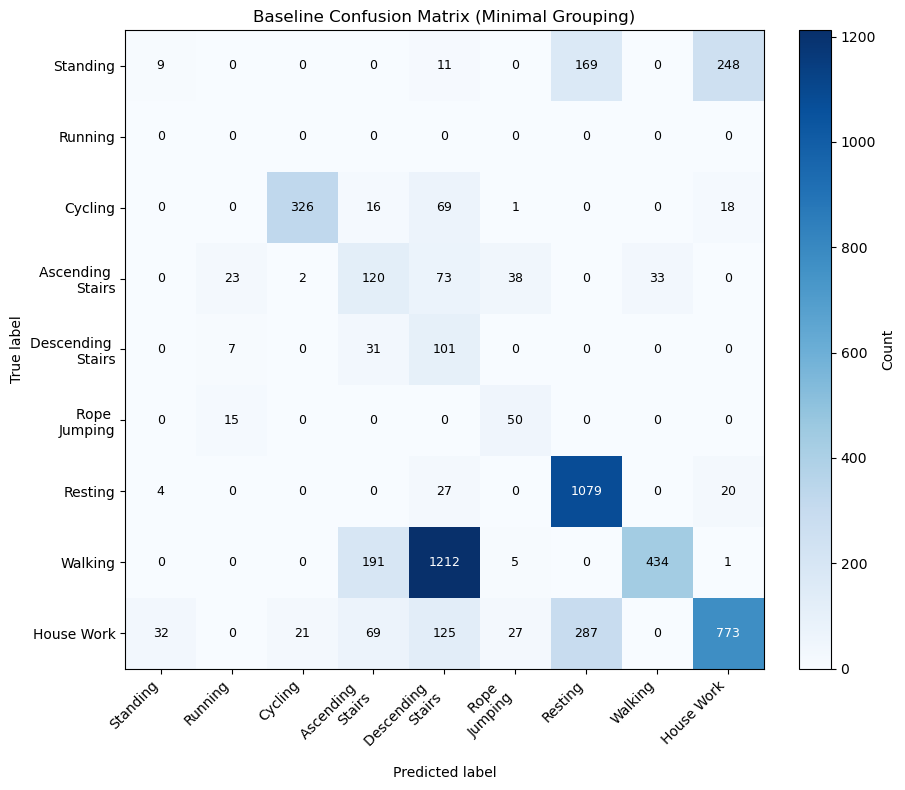

In [81]:
plot_cm(y_true_all_sim,y_pred_all_sim,labels_sim,name_map_sim,name='Minimal Grouping')
plot_cm_test(y_test_sim,y_pred_sim,labels_sim,name_map_sim,name='Minimal Grouping')


Confusion matrix (5-fold pooled predictions):
                   Low \nActivity  Medium \nActivity  High \nActivity
Low \nActivity               3776                844               81
Medium \nActivity             598               4899             3073
High \nActivity                 1                638             1739

Saved confusion group K split matrix PNG: baseline_group_K_split_confusion_matrix_LMH.png


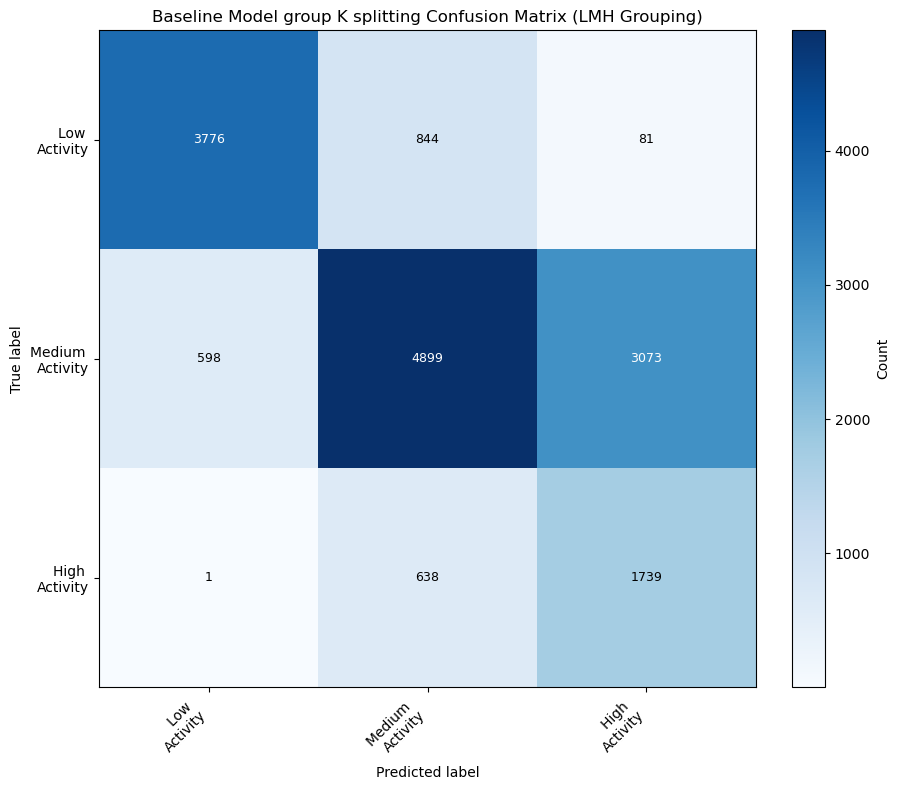


Confusion matrix (test set):
                   Low \nActivity  Medium \nActivity  High \nActivity
Low \nActivity               1268                290                9
Medium \nActivity             393               2055             1157
High \nActivity                 0                266              229

Saved confusion matrix PNG: baseline_confusion_matrix_LMH_grouping.png


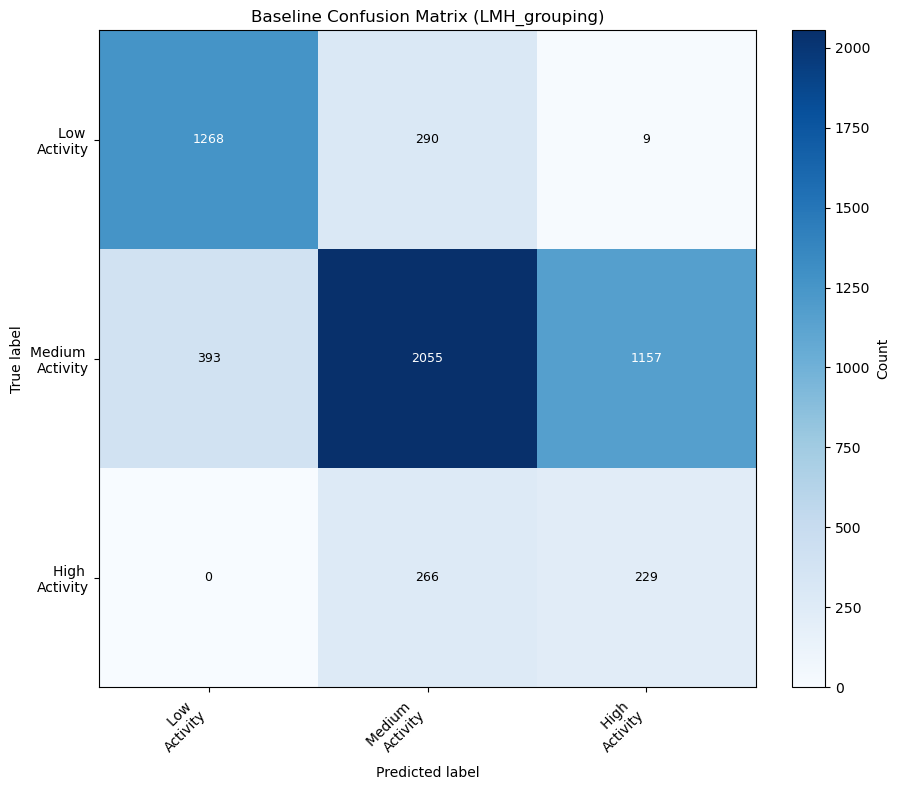

In [82]:
plot_cm(y_true_all_LMH,y_pred_all_LMH,labels_LMH,name_map_LMH,name='LMH Grouping')
plot_cm_test(y_test_LMH,y_pred_LMH,labels_LMH,name_map_LMH,name='LMH_grouping')